In [2]:
#import các thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, QuantileTransformer
)
from sklearn.impute import SimpleImputer, KNNImputer

In [ ]:
data	= pd.read_csv('heart.csv')


In [14]:
#kiểm tra lại các cột còn lại
print(data.columns)

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'ca_missing', 'thal_missing', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality',
       'slope_flat', 'slope_upsloping', 'dataset_Hungary',
       'dataset_Switzerland', 'dataset_VA Long Beach', 'age_<40', 'age_40-50',
       'age_50-60', 'age_>60', 'bp_age_ratio'],
      dtype='str')


In [7]:
#hiện dữ liệu hàng thiếu
print(data.isnull().sum())


age                          0
sex                         45
trestbps                    59
chol                        30
fbs                         45
thalch                      45
exang                       45
oldpeak                     45
ca_missing                  45
thal_missing                45
cp_atypical angina          45
cp_non-anginal              45
cp_typical angina           45
restecg_normal              45
restecg_st-t abnormality    45
slope_flat                  45
slope_upsloping             45
dataset_Hungary             45
dataset_Switzerland         45
dataset_VA Long Beach       45
age_<40                     45
age_40-50                   45
age_50-60                   45
age_>60                     45
bp_age_ratio                59
dtype: int64


In [8]:
#dùng Imputation	để điền giá trị thiếu
imputer = SimpleImputer(strategy='mean')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)
print(data_imputed.head())

    age  sex  trestbps   chol  fbs    thalch  exang   oldpeak  ca_missing  \
0  63.0  1.0     145.0  233.0  0.0 -0.345875    1.0  1.651804         0.0   
1  67.0  1.0     160.0  286.0  0.0  1.961979    0.0  2.502889         0.0   
2  67.0  0.0     120.0  229.0  0.0  1.365120    0.0  0.517024         0.0   
3  37.0  1.0     130.0  250.0  0.0  1.603864    0.0 -0.050366         0.0   
4  41.0  0.0     130.0  204.0  0.0  0.887633    0.0  2.597454         0.0   

   thal_missing  ...  slope_flat  slope_upsloping  dataset_Hungary  \
0           0.0  ...         1.0              0.0              0.0   
1           0.0  ...         0.0              0.0              0.0   
2           0.0  ...         0.0              1.0              0.0   
3           0.0  ...         0.0              1.0              0.0   
4           0.0  ...         0.0              0.0              0.0   

   dataset_Switzerland  dataset_VA Long Beach  age_<40  age_40-50  age_50-60  \
0                  0.0              

In [9]:
#kiểm tra lại dữ liệu sau khi điền giá trị thiếu
print(data_imputed.isnull().sum())

age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca_missing                  0
thal_missing                0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
dataset_Hungary             0
dataset_Switzerland         0
dataset_VA Long Beach       0
age_<40                     0
age_40-50                   0
age_50-60                   0
age_>60                     0
bp_age_ratio                0
dtype: int64


In [10]:
#hiện giá trị các cột age_<40,age_40-50,age_50-60,age_>60
print(data_imputed[['age_<40', 'age_40-50', 'age_50-60', 'age_>60']].head())

   age_<40  age_40-50  age_50-60  age_>60
0      1.0        0.0        0.0      0.0
1      0.0        0.0        0.0      0.0
2      0.0        0.0        0.0      0.0
3      1.0        0.0        0.0      0.0
4      1.0        0.0        0.0      0.0


In [11]:
#kiểm tra age_40-50 có bao nhiêu loại giá trị
print(data_imputed['age_40-50'].value_counts())

age_40-50
0.0    920
Name: count, dtype: int64


In [12]:
#drop các cột age_40-50,age_50-60,age_>60 vì	chỉ còn age_<40 có giá trị khác 0
data_final = data_imputed.drop(columns=['age_40-50', 'age_50-60', 'age_>60'])
print(data_final.head())

    age  sex  trestbps   chol  fbs    thalch  exang   oldpeak  ca_missing  \
0  63.0  1.0     145.0  233.0  0.0 -0.345875    1.0  1.651804         0.0   
1  67.0  1.0     160.0  286.0  0.0  1.961979    0.0  2.502889         0.0   
2  67.0  0.0     120.0  229.0  0.0  1.365120    0.0  0.517024         0.0   
3  37.0  1.0     130.0  250.0  0.0  1.603864    0.0 -0.050366         0.0   
4  41.0  0.0     130.0  204.0  0.0  0.887633    0.0  2.597454         0.0   

   thal_missing  ...  cp_typical angina  restecg_normal  \
0           0.0  ...                0.0             0.0   
1           0.0  ...                0.0             1.0   
2           0.0  ...                0.0             0.0   
3           0.0  ...                0.0             1.0   
4           0.0  ...                0.0             0.0   

   restecg_st-t abnormality  slope_flat  slope_upsloping  dataset_Hungary  \
0                       0.0         1.0              0.0              0.0   
1                       0.0 

In [13]:
#kiểm tra giá trị NaN của sex, trestbps, chol
print(data_final[['sex', 'trestbps', 'chol']].isnull().sum())

sex         0
trestbps    0
chol        0
dtype: int64


In [16]:
#Để dữ liệu thực sự sẵn sàng cho Logistic Regression, bạn nên chạy thêm một bước "quét sạch" cuối cùng như sau:

# Thay thế số 0 bằng NaN: Chuyển các số 0 ở cột trestbps và chol về lại dạng trống.

# Fillna: Sau đó mới dùng fillna(df.mean()) hoặc fillna(df.median()) cho toàn bộ bảng.

# Scaling: Vì Logistic Regression tính toán dựa trên khoảng cách/trọng số, bạn nên dùng StandardScaler để đưa các cột như age, chol, trestbps về cùng một hệ quy chiếu.
# Thay thế số 0 bằng NaN
data_final['trestbps'] = data_final['trestbps'].replace(0, np.nan)
data_final['chol'] = data_final['chol'].replace(0, np.nan)
print(data_final[['trestbps', 'chol']].isnull().sum())

trestbps      1
chol        172
dtype: int64


In [17]:
# Fillna: Sau đó mới dùng fillna(df.mean()) hoặc fillna(df.median()) cho toàn bộ bảng.
data_final = data_final.fillna(data_final.mean())
print(data_final.isnull().sum())


age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca_missing                  0
thal_missing                0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
dataset_Hungary             0
dataset_Switzerland         0
dataset_VA Long Beach       0
age_<40                     0
bp_age_ratio                0
dtype: int64


In [18]:
#đưa	các cột về cùng một hệ quy chiếu bằng StandardScaler
scaler = StandardScaler()
data_final[['age', 'chol', 'trestbps']] = scaler.fit_transform(data_final[['age', 'chol', 'trestbps']])
print(data_final.head())

        age  sex  trestbps      chol  fbs    thalch  exang   oldpeak  \
0  1.007386  1.0  0.710385 -0.227680  0.0 -0.345875    1.0  1.651804   
1  1.432034  1.0  1.547851  0.784682  0.0  1.961979    0.0  2.502889   
2  1.432034  0.0 -0.685393 -0.304084  0.0  1.365120    0.0  0.517024   
3 -1.752828  1.0 -0.127082  0.097040  0.0  1.603864    0.0 -0.050366   
4 -1.328180  0.0 -0.127082 -0.781613  0.0  0.887633    0.0  2.597454   

   ca_missing  thal_missing  ...  cp_typical angina  restecg_normal  \
0         0.0           0.0  ...                0.0             0.0   
1         0.0           0.0  ...                0.0             1.0   
2         0.0           0.0  ...                0.0             0.0   
3         0.0           0.0  ...                0.0             1.0   
4         0.0           0.0  ...                0.0             0.0   

   restecg_st-t abnormality  slope_flat  slope_upsloping  dataset_Hungary  \
0                       0.0         1.0              0.0       

In [27]:
import pandas as pd

# Dùng đường dẫn tuyệt đối
data_goc = pd.read_csv(r"E:\heart predict\data\raw_data\heart_disease_uci.csv")
print(data_goc.head())


   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [28]:
#lấy cột id và	num từ data_goc
df_label = data_goc[['id', 'num']]
print(df_label.head())

   id  num
0   1    0
1   2    2
2   3    1
3   4    0
4   5    0


In [30]:
#3. Ghép trực tiếp bằng concat (vì số dòng 920 là khớp tuyệt đối)
df_final = pd.concat([data_final, df_label['num']], axis=1)
print(df_final.head())

        age  sex  trestbps      chol  fbs    thalch  exang   oldpeak  \
0  1.007386  1.0  0.710385 -0.227680  0.0 -0.345875    1.0  1.651804   
1  1.432034  1.0  1.547851  0.784682  0.0  1.961979    0.0  2.502889   
2  1.432034  0.0 -0.685393 -0.304084  0.0  1.365120    0.0  0.517024   
3 -1.752828  1.0 -0.127082  0.097040  0.0  1.603864    0.0 -0.050366   
4 -1.328180  0.0 -0.127082 -0.781613  0.0  0.887633    0.0  2.597454   

   ca_missing  thal_missing  ...  restecg_normal  restecg_st-t abnormality  \
0         0.0           0.0  ...             0.0                       0.0   
1         0.0           0.0  ...             1.0                       0.0   
2         0.0           0.0  ...             0.0                       0.0   
3         0.0           0.0  ...             1.0                       0.0   
4         0.0           0.0  ...             0.0                       0.0   

   slope_flat  slope_upsloping  dataset_Hungary  dataset_Switzerland  \
0         1.0             

In [36]:
#kiem tra bp_age_ratio đã scale chưa
print(df_final['bp_age_ratio'].head())

0    2.301587
1    2.388060
2    1.791045
3    3.513514
4    3.170732
Name: bp_age_ratio, dtype: float64


In [37]:
#scaler bp_age_ratio
scaler = StandardScaler()
df_final['bp_age_ratio'] = scaler.fit_transform(df_final[['bp_age_ratio']])
print(df_final['bp_age_ratio'].head())

0   -0.486431
1   -0.321676
2   -1.459160
3    1.822634
4    1.169537
Name: bp_age_ratio, dtype: float64


In [35]:
#df.fillna() cho toàn bộ 920 dòng
df_final	= df_final.fillna(df_final.mean())
print(df_final.isnull().sum())

age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca_missing                  0
thal_missing                0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
dataset_Hungary             0
dataset_Switzerland         0
dataset_VA Long Beach       0
age_<40                     0
bp_age_ratio                0
num                         0
dtype: int64


In [38]:
#save data	đã xử lý lại 
df_final.to_csv('processed_heart_data_final.csv', index=False)

In [56]:
#import data de train model
data = pd.read_csv('processed_heart_data_final.csv')
print(data.head())

        age  sex  trestbps      chol  fbs    thalch  exang   oldpeak  \
0  1.007386  1.0  0.710385 -0.227680  0.0 -0.345875    1.0  1.651804   
1  1.432034  1.0  1.547851  0.784682  0.0  1.961979    0.0  2.502889   
2  1.432034  0.0 -0.685393 -0.304084  0.0  1.365120    0.0  0.517024   
3 -1.752828  1.0 -0.127082  0.097040  0.0  1.603864    0.0 -0.050366   
4 -1.328180  0.0 -0.127082 -0.781613  0.0  0.887633    0.0  2.597454   

   ca_missing  thal_missing  ...  restecg_normal  restecg_st-t abnormality  \
0         0.0           0.0  ...             0.0                       0.0   
1         0.0           0.0  ...             1.0                       0.0   
2         0.0           0.0  ...             0.0                       0.0   
3         0.0           0.0  ...             1.0                       0.0   
4         0.0           0.0  ...             0.0                       0.0   

   slope_flat  slope_upsloping  dataset_Hungary  dataset_Switzerland  \
0         1.0             

In [54]:
# Chuyển tất cả giá trị > 0 (1, 2, 3, 4) thành 1
df_final['num'] = df_final['num'].apply(lambda x: 1 if x > 0 else 0)
print(df_final['num'].value_counts())

num
1    509
0    411
Name: count, dtype: int64


In [55]:
#lưu lại data đã xử lý
df_final.to_csv('processed_heart_data_final.csv', index=False)

In [40]:
#kiểm tra còn ID không
print(data.columns)

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'ca_missing', 'thal_missing', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality',
       'slope_flat', 'slope_upsloping', 'dataset_Hungary',
       'dataset_Switzerland', 'dataset_VA Long Beach', 'age_<40',
       'bp_age_ratio', 'num'],
      dtype='str')


In [48]:
# Chuyển tất cả giá trị > 0 (1, 2, 3, 4) thành 1
df_final['num'] = df_final['num'].apply(lambda x: 1 if x > 0 else 0)
print(df_final['num'].value_counts())

num
1    509
0    411
Name: count, dtype: int64


In [67]:
X = data.drop(columns=['num'])
y = data['num']

X_train, X_test, y_train, y_test = train_test_split(X, y,	test_size=0.2, random_state=42)

model = LogisticRegression(C=0.1, max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [68]:
#dự đoán và đánh giá mô hình
from sklearn.metrics import accuracy_score, classification_report


y_pred = model.predict(X_test)
print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nBáo cáo chi tiết:")
print(classification_report(y_test, y_pred))
	

Độ chính xác (Accuracy): 0.78

Báo cáo chi tiết:
              precision    recall  f1-score   support

           0       0.72      0.76      0.74        75
           1       0.83      0.80      0.81       109

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.78      0.78      0.78       184



In [69]:
#lưu	mô hình đã train
joblib.dump(model, 'heart_disease_model.pkl')

['heart_disease_model.pkl']

In [70]:
#lưu scaler
joblib.dump(scaler, 'scaler.pkl')
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')
print("Mô hình, scaler và tên đặc trưng đã được lưu thành công.")

Mô hình, scaler và tên đặc trưng đã được lưu thành công.


In [71]:
#thử với random forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
# 2. Huấn luyện
rf_model.fit(X_train, y_train)

# 3. Dự đoán và đánh giá
y_pred_rf = rf_model.predict(X_test)

print(f"Độ chính xác Random Forest: {accuracy_score(y_test, y_pred_rf):.2f}")
print(classification_report(y_test, y_pred_rf))

Độ chính xác Random Forest: 0.78
              precision    recall  f1-score   support

           0       0.71      0.76      0.74        75
           1       0.83      0.79      0.81       109

    accuracy                           0.78       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.78      0.78      0.78       184



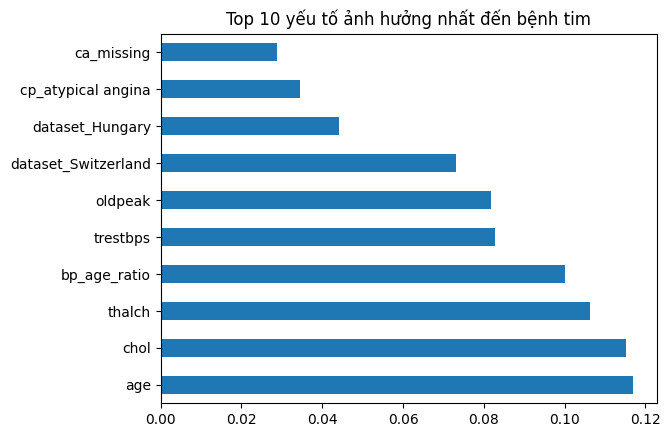

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 yếu tố ảnh hưởng nhất đến bệnh tim')
plt.show()

In [75]:
import re

# Hàm để thay thế các ký tự lạ bằng dấu gạch dưới (_)
def clean_feature_names(df):
    new_cols = [re.sub(r'[\[\]<]', '_', col) for col in df.columns]
    df.columns = new_cols
    return df

# Làm sạch tên cột cho cả tập Train và Test
X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

# Sau đó mới chạy XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

e:\heart predict\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:40:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [76]:
#đánh	giá mô hình XGBoost
y_pred_xgb = xgb_model.predict(X_test)
print(f"Độ chính xác XGBoost: {accuracy_score(y_test, y_pred_xgb):.2f}")
print(classification_report(y_test, y_pred_xgb))	


Độ chính xác XGBoost: 0.76
              precision    recall  f1-score   support

           0       0.69      0.72      0.71        75
           1       0.80      0.78      0.79       109

    accuracy                           0.76       184
   macro avg       0.75      0.75      0.75       184
weighted avg       0.76      0.76      0.76       184



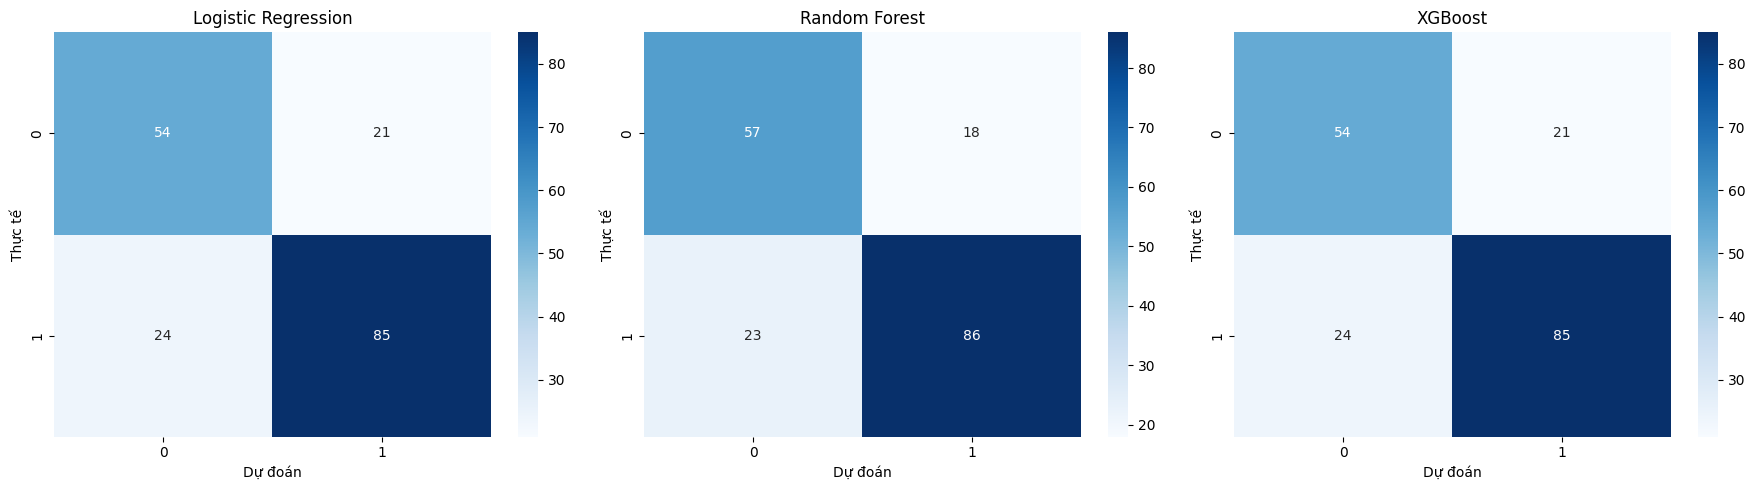

In [78]:
#ma trận nhầm lẫn so sánh 3	mô hình gộp	vào một biểu đồ
from sklearn.metrics import confusion_matrix
import seaborn as sns
models = {
				'Logistic Regression': y_pred,
				'Random Forest': y_pred_rf,
				'XGBoost': y_pred_xgb
}	
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, y_pred_model) in zip(axes, models.items()):
				cm = confusion_matrix(y_test, y_pred_model)
				sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
				ax.set_title(model_name)
				ax.set_xlabel('Dự đoán')
				ax.set_ylabel('Thực tế')
plt.tight_layout()
plt.show()

In [79]:
#số ca dự đoán đúng của từng mô hình
for model_name, y_pred_model in models.items():
				cm = confusion_matrix(y_test, y_pred_model)
				tp = cm[1, 1]  # True Positives
				tn = cm[0, 0]  # True Negatives
				print(f"{model_name}: Dự đoán đúng {tp + tn} ca trên tổng số {len(y_test)} ca.")

Logistic Regression: Dự đoán đúng 139 ca trên tổng số 184 ca.
Random Forest: Dự đoán đúng 143 ca trên tổng số 184 ca.
XGBoost: Dự đoán đúng 139 ca trên tổng số 184 ca.


In [82]:
#lưu random forest
joblib.dump(rf_model, 'random_forest_model.pkl')
# 2. Lưu bộ chuẩn hóa Scaler (cái này cực kỳ quan trọng để dùng cho dữ liệu mới)
joblib.dump(scaler, 'heart_scaler.pkl')

# 3. Lưu danh sách tên cột (để sau này nạp dữ liệu đúng thứ tự)
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

print("Đã lưu Random Forest và các phụ kiện thành công!")

Đã lưu Random Forest và các phụ kiện thành công!


In [84]:
import joblib
scaler = joblib.load(r"E:\heart predict\notebook\heart_scaler.pkl")
# In ra danh sách cột mà scaler đã học
if hasattr(scaler, 'feature_names_in_'):
    print("Danh sách cột chuẩn:")
    print(scaler.feature_names_in_)
else:
    print("Scaler này được train từ Numpy array, không có tên cột.")

Danh sách cột chuẩn:
['bp_age_ratio']


In [85]:
import joblib

# Load cả model và scaler
model = joblib.load(r"E:\heart predict\notebook\heart_disease_model.pkl") # Thay tên model của bạn
scaler = joblib.load(r"E:\heart predict\notebook\heart_scaler.pkl")

print("--- KIỂM TRA SCALER ---")
if hasattr(scaler, 'feature_names_in_'):
    print(f"Số lượng cột scaler cần: {len(scaler.feature_names_in_)}")
    print(f"Các cột: {scaler.feature_names_in_}")

print("\n--- KIỂM TRA MODEL ---")
if hasattr(model, 'feature_names_in_'):
    print(f"Số lượng cột model cần: {len(model.feature_names_in_)}")
    print(f"Các cột: {model.feature_names_in_}")

--- KIỂM TRA SCALER ---
Số lượng cột scaler cần: 1
Các cột: ['bp_age_ratio']

--- KIỂM TRA MODEL ---
Số lượng cột model cần: 22
Các cột: ['age' 'sex' 'trestbps' 'chol' 'fbs' 'thalch' 'exang' 'oldpeak'
 'ca_missing' 'thal_missing' 'cp_atypical angina' 'cp_non-anginal'
 'cp_typical angina' 'restecg_normal' 'restecg_st-t abnormality'
 'slope_flat' 'slope_upsloping' 'dataset_Hungary' 'dataset_Switzerland'
 'dataset_VA Long Beach' 'age_<40' 'bp_age_ratio']


In [91]:
import joblib
scaler = joblib.load("heart_scaler.pkl")

if hasattr(scaler, "feature_names_in_"):
    print("Scaler đã học các cột:")
    print(scaler.feature_names_in_)
else:
    print("Scaler này được train từ Numpy array, không có tên cột.")


Scaler đã học các cột:
['age' 'sex' 'trestbps' 'chol' 'fbs' 'thalch' 'exang' 'oldpeak'
 'ca_missing' 'thal_missing' 'cp_atypical angina' 'cp_non-anginal'
 'cp_typical angina' 'restecg_normal' 'restecg_st-t abnormality'
 'slope_flat' 'slope_upsloping' 'dataset_Hungary' 'dataset_Switzerland'
 'dataset_VA Long Beach' 'age__40' 'bp_age_ratio']


In [89]:
#kiểm tra mô hình đã học những cột nào
model = joblib.load("heart_disease_model.pkl")
if hasattr(model, "feature_names_in_"):
				print("Model đã học các cột:")
				print(model.feature_names_in_)	
else:				print("Model này được train từ Numpy array, không có tên cột.")

Model đã học các cột:
['age' 'sex' 'trestbps' 'chol' 'fbs' 'thalch' 'exang' 'oldpeak'
 'ca_missing' 'thal_missing' 'cp_atypical angina' 'cp_non-anginal'
 'cp_typical angina' 'restecg_normal' 'restecg_st-t abnormality'
 'slope_flat' 'slope_upsloping' 'dataset_Hungary' 'dataset_Switzerland'
 'dataset_VA Long Beach' 'age_<40' 'bp_age_ratio']


In [90]:
#lưu lại scaler với 22	cột đã được làm sạch tên
heart_scaler = StandardScaler()
heart_scaler.fit(X_train)  
joblib.dump(heart_scaler, "heart_scaler.pkl")

['heart_scaler.pkl']